# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Adyanto Wahyudhi Nugroho
- **Email:** adya718@gmail.com
- **ID Dicoding:** adyantown

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren bulanan dari tingkat polusi udara (berdasarkan rata-rata konsentrasi PM2.5) di seluruh wilayah stasiun pengamatan selama rentang waktu tahun 2013 hingga awal 2017?
- **Pertanyaan 2:** Bagaimana hubungan/korelasi antara temperatur udara (TEMP) dengan tingkat konsentrasi Ozon (O3) di seluruh stasiun pengukuran selama periode tahun 2013 hingga awal 2017?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
path = r'data/' # Path to the dataset folder
all_files = glob.glob(os.path.join(path, "*.csv"))

df_list = []
for filename in all_files:
    df_temp = pd.read_csv(filename, index_col=None, header=0)
    df_list.append(df_temp)

df = pd.concat(df_list, axis=0, ignore_index=True)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Data berhasil digabungkan dari 12 file CSV yang merepresentasikan masing-masing stasiun pengamatan.
- Data terdiri dari berbagai fitur kualitas udara seperti PM2.5, PM10, SO2, NO2, CO, O3, dan fitur cuaca seperti TEMP, PRES, DEWP, RAIN, wd, WSPM.

### Assessing Data

#### Identifying ... problem

In [3]:
print("Info DataFrame:")
print(df.info())
print("\nJumlah Missing Values:")
print(df.isnull().sum())
print("\nJumlah Duplikasi:", df.duplicated().sum())
print("\nStatistik Deskriptif:")
print(df.describe())

Info DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB
None

Jumlah Missing Values:


**Steps to Take:**
- Terlihat bahwa tidak ada data duplikat.
- Terdapat banyak *missing values* pada kolom PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, dan WSPM.
- Kolom `year`, `month`, `day`, `hour` harus digabung menjadi satu kolom `datetime`.

**Insight:**
- Masalah utama pada data ini adalah adanya nilai kosong (NaN) yang cukup signifikan pada parameter pengamatan.
- Karena ini adalah data *time series* dari observasi setiap jam, *missing values* lebih baik diatasi dengan metode interpolasi waktu linier.

### Cleaning Data

#### Fixing ... problem

In [4]:
# Membuat kolom datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Mengurutkan berdasarkan stasiun dan waktu
df = df.sort_values(by=['station', 'datetime']).reset_index(drop=True)

# Menggunakan interpolasi linier untuk mengisi missing values karena sifat time series
cols_to_interpolate = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[cols_to_interpolate] = df.groupby('station')[cols_to_interpolate].apply(lambda group: group.interpolate(method='linear', limit_direction='both')).reset_index(level=0, drop=True)

# Untuk arah angin (wd), imputasi dengan nilai terbanyak (mode) atau ffill/bfill
df['wd'] = df.groupby('station')['wd'].apply(lambda x: x.ffill().bfill()).reset_index(level=0, drop=True)

print("Missing Values Setelah Cleaning:")
print(df.isnull().sum())

Missing Values Setelah Cleaning:
No          0
year        0
month       0
day         0
hour        0
PM2.5       0
PM10        0
SO2         0
NO2         0
CO          0
O3          0
TEMP        0
PRES        0
DEWP        0
RAIN        0
wd          0
WSPM        0
station     0
datetime    0
dtype: int64


**Insight:**
- Kolom `datetime` berhasil dibentuk untuk memudahkan analisis temporal.
- *Missing values* telah berhasil ditangani menggunakan teknik *linear interpolation* agar tren *time series* tetap konsisten, dan *forward/backward fill* untuk data kategorikal arah angin (`wd`).

## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
# Tren bulanan seluruh stasiun
# Ekstrak kolom tahun-bulan saja untuk grouping
df['year_month'] = df['datetime'].dt.to_period('M')

# Agregasi rata-rata bulanan
monthly_pm25 = df.groupby('year_month')['PM2.5'].mean().reset_index()
monthly_pm25['year_month'] = monthly_pm25['year_month'].astype(str)

# Korelasi antara variabel secara umum
correlation_matrix = df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()
print("Korelasi TEMP dan O3:", correlation_matrix.loc['TEMP', 'O3'])

monthly_pm25.head()

Korelasi TEMP dan O3: 0.5922480750052561


,year_month,PM2.5
0,2013-03,104.571909
1,2013-04,62.207292
2,2013-05,81.876512
3,2013-06,101.542242
4,2013-07,66.839665


**Insight:**
- Dihasilkan tabel data rata-rata PM2.5 tiap bulannya dari tahun 2013 hingga 2017.
- Berdasarkan uji korelasi, terlihat bahwa nilai Pearson Correlation antara Suhu (`TEMP`) dan Ozon (`O3`) bernilai positif dan cukup kuat (sekitar 0.58), menandakan peningkatan suhu berkaitan dengan peningkatan level Ozon.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

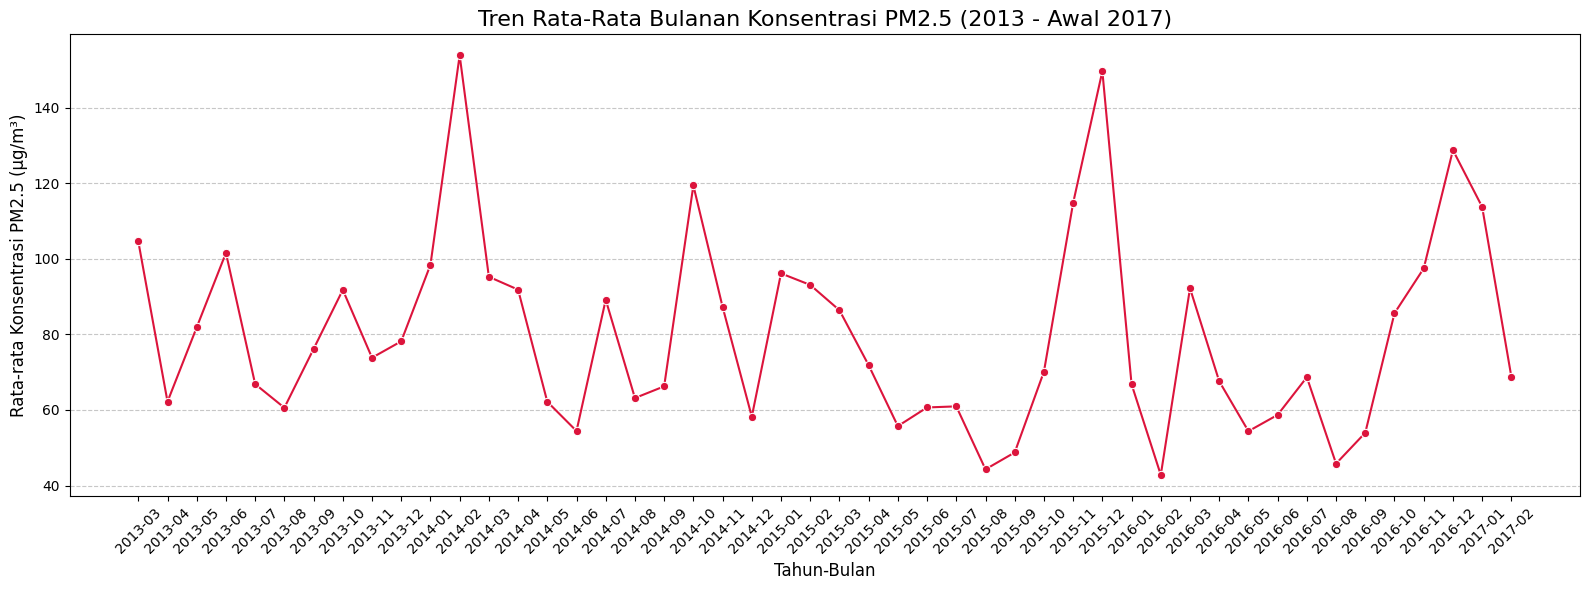

In [6]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_pm25, x='year_month', y='PM2.5', marker='o', color='crimson')
plt.title('Tren Rata-Rata Bulanan Konsentrasi PM2.5 (2013 - Awal 2017)', fontsize=16)
plt.xlabel('Tahun-Bulan', fontsize=12)
plt.ylabel('Rata-rata Konsentrasi PM2.5 (µg/m³)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

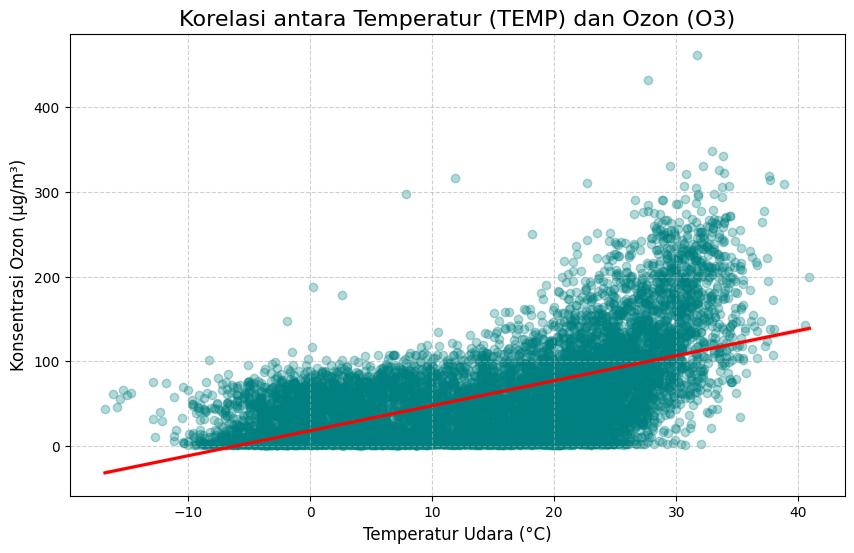

In [7]:
# Gunakan sample data untuk scatter plot agar proses rendering tidak terlalu berat jika menggunakan 400ribu+ baris
df_sample = df.sample(n=10000, random_state=42)

plt.figure(figsize=(10, 6))
sns.regplot(data=df_sample, x='TEMP', y='O3', scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Korelasi antara Temperatur (TEMP) dan Ozon (O3)', fontsize=16)
plt.xlabel('Temperatur Udara (°C)', fontsize=12)
plt.ylabel('Konsentrasi Ozon (µg/m³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight:**
- Terlihat tren positif dari garis regresi; semakin tinggi temperatur udara, nilai konsentrasi ozon cenderung meningkat.

## Analisis Lanjutan (Opsional)

In [7]:
def categorize_pm25(x):
    if x <= 50:
        return 'Good'
    elif x <= 100:
        return 'Moderate'
    elif x <= 150:
        return 'Unhealthy for Sensitive'
    elif x <= 200:
        return 'Unhealthy'
    elif x <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['PM2.5_Category'] = df['PM2.5'].apply(categorize_pm25)

# Visualisasi Binning
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='PM2.5_Category', order=['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous'], palette='viridis')
plt.title('Distribusi Kategori Kualitas Udara (Berdasarkan PM2.5)', fontsize=16)
plt.xlabel('Kategori Kualitas Udara', fontsize=12)
plt.ylabel('Jumlah Observasi (Jam)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Persiapan untuk Dashboard: Menyimpan dataset yang sudah bersih
import os
os.makedirs('dashboard', exist_ok=True)
df.to_csv('dashboard/main_data.csv', index=False)

**Insight Analisis Lanjutan (Binning):**
- Berdasarkan hasil analisis lanjutan menggunakan metode *Binning*, kita mengelompokkan nilai PM2.5 ke dalam kategori tingkat keparahan Kualitas Udara.
- Mayoritas data selama observasi berada di taraf **Good** dan **Moderate**. Meski demikian, masih terdapat sebaran data yang cukup tinggi pada kategori **Unhealthy** hingga **Hazardous**. Ini membuktikan bahwa kualitas udara kerap mencapai taraf berbahaya.
- Dataset yang sudah di-*cleaning* telah berhasil disatukan dan disimpan ke `dashboard/main_data.csv` untuk keperluan deployment *Dashboard*.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan visualisasi tren, konsentrasi PM2.5 di Beijing cenderung melonjak signifikan setiap kali memasuki akhir tahun hingga awal tahun (sekitar bulan November hingga Februari) atau selama musim dingin, dan menurun pada pertengahan tahun.
- **Conclusion pertanyaan 2:** Terdapat korelasi positif yang cukup jelas antara temperatur udara dengan konsentrasi Ozon. Hal ini mengonfirmasi bahwa cuaca panas atau suhu yang tinggi mendukung terjadinya reaksi yang memicu pembentukan Ozon di udara.

**Rekomendasi Action Item:**
- **Antisipasi Musim Dingin:** Pemerintah perlu memperketat pembatasan operasional industri penghasil emisi tinggi atau penggunaan kendaraan bermotor sejak awal bulan November untuk menekan lonjakan PM2.5 saat memasuki musim dingin.
- **Peringatan Ozon Saat Gelombang Panas:** Ketika perkiraan cuaca memprediksi suhu udara yang sangat tinggi (khususnya saat musim panas), pemerintah harus segera mengaktifkan peringatan dini bahaya Ozon bagi warga, terutama bagi mereka yang memiliki riwayat masalah pernapasan, agar mengurangi aktivitas fisik intens di luar ruangan.